# DM - Python pour la Data Science

In [ ]:
# Packages à installer - fichier requirements.txt
!pip install -r requirements.txt

In [25]:
# Imports nécessaires
import pandas as pd

from fonctions.fct_filtre import filtre_Aude
from fonctions.fct_tableau import tableau_propre, tableau_propre_2
from fonctions.fct_graphique import top5_surrepresentation, carte, score_candidat

## Importation des données

In [26]:
df = pd.read_csv(
    'https://www.data.gouv.fr/fr/datasets/r/182268fc-2103-4bcb-a850-6cf90b02a9eb'
)

/tmp/ipykernel_4643/11982682.py:1: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(


In [27]:
df.head(2)

,code_departement,libelle_departement,code_commune,libelle_commune,prenom,nom,voix
0,01,Ain,1,L'Abergement-Clémenciat,Nathalie,ARTHAUD,3
1,01,Ain,2,L'Abergement-de-Varey,Nathalie,ARTHAUD,2


## 1. Explorations générales

### Question n°1

In [28]:
# Modification de code_commune
df["code_commune"] = (
    df["code_departement"].astype(str)
    + df["code_commune"].astype(str).str.rjust(3, "0")
)

# Création de la colonne candidat (prenom + nom)
df["candidat"] = (df["prenom"].fillna("") + " " + df["nom"].fillna("")).str.strip()


#### Vérification Q1

In [29]:
df[df["libelle_commune"] == "Montrouge"]
# nous avons bien le code commune 92049

,code_departement,libelle_departement,code_commune,libelle_commune,prenom,nom,voix,candidat
34535,92,Hauts-de-Seine,92049,Montrouge,Nathalie,ARTHAUD,96,Nathalie ARTHAUD
69780,92,Hauts-de-Seine,92049,Montrouge,Fabien,ROUSSEL,499,Fabien ROUSSEL
105025,92,Hauts-de-Seine,92049,Montrouge,Emmanuel,MACRON,8291,Emmanuel MACRON
140270,92,Hauts-de-Seine,92049,Montrouge,Jean,LASSALLE,349,Jean LASSALLE
175515,92,Hauts-de-Seine,92049,Montrouge,Marine,LE PEN,1775,Marine LE PEN
210760,92,Hauts-de-Seine,92049,Montrouge,Éric,ZEMMOUR,1466,Éric ZEMMOUR
246005,92,Hauts-de-Seine,92049,Montrouge,Jean-Luc,MÉLENCHON,6683,Jean-Luc MÉLENCHON
281250,92,Hauts-de-Seine,92049,Montrouge,Anne,HIDALGO,508,Anne HIDALGO
316495,92,Hauts-de-Seine,92049,Montrouge,Yannick,JADOT,1952,Yannick JADOT
351740,92,Hauts-de-Seine,92049,Montrouge,Valérie,PÉCRESSE,1468,Valérie PÉCRESSE


### Question n°2

In [30]:
# nombre de candidat
candidats = df["candidat"].nunique() - 3

In [31]:
f"En 2022, il y avait {candidats} candidats à l'élection présidentielle."

"En 2022, il y avait 12 candidats à l'élection présidentielle."

### Question n°3

In [32]:
# Création df scores, votes par candidat
scores = ( df[~df["candidat"].isin(["abstentions", "blancs", "nuls"])]
           .groupby("candidat")
           .sum("voix")
           .sort_values(ascending = False, by = "voix")
           .reset_index()
        )

scores["pourcentage"] = scores["voix"]/scores["voix"].sum()

In [33]:
tableau_propre(scores)

GT(_tbl_data=                 candidat     voix  pourcentage
0         Emmanuel MACRON  9783058     0.278458
1           Marine LE PEN  8133828     0.231516
2      Jean-Luc MÉLENCHON  7712520     0.219524
3            Éric ZEMMOUR  2485226     0.070738
4        Valérie PÉCRESSE  1679001     0.047790
5           Yannick JADOT  1627853     0.046334
6           Jean LASSALLE  1101387     0.031349
7          Fabien ROUSSEL   802422     0.022840
8   Nicolas DUPONT-AIGNAN   725176     0.020641
9            Anne HIDALGO   616478     0.017547
10        Philippe POUTOU   268904     0.007654
11       Nathalie ARTHAUD   197094     0.005610, _body=<great_tables._gt_data.Body object at 0x7f5f5b2f3690>, _boxhead=Boxhead([ColInfo(var='candidat', type=<ColInfoTypeEnum.default: 1>, column_label='Candidat', column_align='left', column_width=None), ColInfo(var='voix', type=<ColInfoTypeEnum.default: 1>, column_label='Nombre de votes (total)', column_align='right', column_width=None), ColInfo(var='pourcentage', type=<ColInfoTypeEnum.default: 1>, column_label='Score (% votes exprimés)', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x7f603823d220>, _spanners=Spanners([]), _heading=Heading(title='Élections', subtitle='Résultats des votes du premier tour', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x7f5f57cc3650>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x7f5f57cc3b50>, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x7f5f5a6eb950>, _formats=[<great_tables._gt_data.FormatInfo object at 0x7f5f5b205400>, <great_tables._gt_data.FormatInfo object at 0x7f5f5b2057c0>], _substitutions=[], _col_merge=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_right_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_right_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_right_color=OptionsInfo(scss=True, category='table', type='value', value='#D3D3D3'), table_border_bottom_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_bottom_style=OptionsInfo(scss=True, category='table', type='value', value='s

## 2. Comparaison des scores départements aux moyennes nationales.

### Question n°4

In [34]:
# Création df, votes par candidat et departements
score_departements = ( df[~df["candidat"].isin(["abstentions", "blancs", "nuls"])]
                      .groupby(["code_departement", "candidat"])
                      .sum("voix")
                      .sort_values(ascending = [True, False], by = ["code_departement","voix"])
                      .reset_index()
                     )

score_departements["pourcentage"] = score_departements["voix"]/score_departements.groupby("code_departement")["voix"].transform("sum")

In [35]:
tableau_propre(score_departements.head(15), par_dep=True)

GT(_tbl_data=   code_departement               candidat    voix  pourcentage
0                01        Emmanuel MACRON   92206     0.276875
1                01          Marine LE PEN   86755     0.260507
2                01     Jean-Luc MÉLENCHON   57832     0.173657
3                01           Éric ZEMMOUR   27530     0.082667
4                01       Valérie PÉCRESSE   17572     0.052765
5                01          Yannick JADOT   15843     0.047573
6                01          Jean LASSALLE   10876     0.032658
7                01  Nicolas DUPONT-AIGNAN    8998     0.027019
8                01         Fabien ROUSSEL    5938     0.017831
9                01           Anne HIDALGO    5644     0.016948
10               01        Philippe POUTOU    2172     0.006522
11               01       Nathalie ARTHAUD    1658     0.004979
12               02          Marine LE PEN  104342     0.392470
13               02        Emmanuel MACRON   58721     0.220872
14               02     Jean-Luc MÉLENCHON   41172     0.154863, _body=<great_tables._gt_data.Body object at 0x7f5f5b1f5e50>, _boxhead=Boxhead([ColInfo(var='code_departement', type=<ColInfoTypeEnum.default: 1>, column_label='Code departement', column_align='right', column_width=None), ColInfo(var='candidat', type=<ColInfoTypeEnum.default: 1>, column_label='Candidat', column_align='left', column_width=None), ColInfo(var='voix', type=<ColInfoTypeEnum.default: 1>, column_label='Nombre de votes (total)', column_align='right', column_width=None), ColInfo(var='pourcentage', type=<ColInfoTypeEnum.default: 1>, column_label='Score (% votes exprimés)', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x7f5f5b4430b0>, _spanners=Spanners([]), _heading=Heading(title='Élections', subtitle='Résultats des votes du premier tour par département', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x7f5f5b205a90>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x7f5f5b205c70>, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x7f5f5ad53650>, _formats=[<great_tables._gt_data.FormatInfo object at 0x7f5f5b2f3a10>, <great_tables._gt_data.FormatInfo object at 0x7f5f5b2f3310>], _substitutions=[], _col_merge=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_bord

#### Vérification Q4 pour l'Aude (département n°11)

In [36]:
aude = filtre_Aude(score_departements)

In [37]:
tableau_propre(aude, par_dep=True)

GT(_tbl_data=    code_departement               candidat   voix  pourcentage
120               11          Marine LE PEN  64027     0.301408
121               11        Emmanuel MACRON  43104     0.202913
122               11     Jean-Luc MÉLENCHON  42039     0.197900
123               11           Éric ZEMMOUR  18434     0.086778
124               11          Jean LASSALLE  12382     0.058289
125               11       Valérie PÉCRESSE   7350     0.034600
126               11          Yannick JADOT   6322     0.029761
127               11           Anne HIDALGO   6166     0.029027
128               11         Fabien ROUSSEL   5622     0.026466
129               11  Nicolas DUPONT-AIGNAN   4206     0.019800
130               11        Philippe POUTOU   1748     0.008229
131               11       Nathalie ARTHAUD   1026     0.004830, _body=<great_tables._gt_data.Body object at 0x7f5f59461390>, _boxhead=Boxhead([ColInfo(var='code_departement', type=<ColInfoTypeEnum.default: 1>, column_label='Code departement', column_align='right', column_width=None), ColInfo(var='candidat', type=<ColInfoTypeEnum.default: 1>, column_label='Candidat', column_align='left', column_width=None), ColInfo(var='voix', type=<ColInfoTypeEnum.default: 1>, column_label='Nombre de votes (total)', column_align='right', column_width=None), ColInfo(var='pourcentage', type=<ColInfoTypeEnum.default: 1>, column_label='Score (% votes exprimés)', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x7f5f5ad5d7b0>, _spanners=Spanners([]), _heading=Heading(title='Élections', subtitle='Résultats des votes du premier tour par département', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x7f5f5b2f3bd0>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x7f5f5ae00050>, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x7f5f5ad5c6b0>, _formats=[<great_tables._gt_data.FormatInfo object at 0x7f5f5ad72a90>, <great_tables._gt_data.FormatInfo object at 0x7f5f5b1f71d0>], _substitutions=[], _col_merge=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_right_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_borde

### Question n°5

In [38]:
# Rajout des votes à l'échelle national
score_departements = score_departements.merge(
    scores,
    on="candidat",
    suffixes=("_dep", "_nat")
).sort_values(ascending=[True, False], by=["code_departement", "voix_dep"])


#### Vérification Q5 pour l'Aude

In [39]:
aude2 = filtre_Aude(score_departements)

In [40]:
tableau_propre_2(aude2)

GT(_tbl_data=    code_departement               candidat  voix_dep  pourcentage_dep  \
120               11          Marine LE PEN     64027         0.301408   
121               11        Emmanuel MACRON     43104         0.202913   
122               11     Jean-Luc MÉLENCHON     42039         0.197900   
123               11           Éric ZEMMOUR     18434         0.086778   
124               11          Jean LASSALLE     12382         0.058289   
125               11       Valérie PÉCRESSE      7350         0.034600   
126               11          Yannick JADOT      6322         0.029761   
127               11           Anne HIDALGO      6166         0.029027   
128               11         Fabien ROUSSEL      5622         0.026466   
129               11  Nicolas DUPONT-AIGNAN      4206         0.019800   
130               11        Philippe POUTOU      1748         0.008229   
131               11       Nathalie ARTHAUD      1026         0.004830   

     voix_nat  pourcentage_nat  
120   8133828         0.231516  
121   9783058         0.278458  
122   7712520         0.219524  
123   2485226         0.070738  
124   1101387         0.031349  
125   1679001         0.047790  
126   1627853         0.046334  
127    616478         0.017547  
128    802422         0.022840  
129    725176         0.020641  
130    268904         0.007654  
131    197094         0.005610  , _body=<great_tables._gt_data.Body object at 0x7f5f5b2dc950>, _boxhead=Boxhead([ColInfo(var='code_departement', type=<ColInfoTypeEnum.default: 1>, column_label='Code departement', column_align='right', column_width=None), ColInfo(var='candidat', type=<ColInfoTypeEnum.default: 1>, column_label='Candidat', column_align='left', column_width=None), ColInfo(var='voix_dep', type=<ColInfoTypeEnum.default: 1>, column_label='Votes par département (total)', column_align='right', column_width=None), ColInfo(var='pourcentage_dep', type=<ColInfoTypeEnum.default: 1>, column_label='Score par departement (% votes exprimés)', column_align='right', column_width=None), ColInfo(var='voix_nat', type=<ColInfoTypeEnum.default: 1>, column_label='Votes national (total)', column_align='right', column_width=None), ColInfo(var='pourcentage_nat', type=<ColInfoTypeEnum.default: 1>, column_label='Score national (% votes exprimés)', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x7f5f5ad5dae0>, _spanners=Spanners([]), _heading=Heading(title='Élections', subtitle="Résultats des votes du premier tour pour l'Aude", preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x7f5f5ad72270>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x7f5f5b360290>, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x7f5f5ad5d9d0>, _formats=[<great_tables._gt_data.FormatInfo object at 0x7f5f5b361250>, <great_tables._gt_data.FormatInfo object at 0x7f5f59461440>, <great_tables._gt_data.FormatInfo object at 0x7f5f59461180>, <great_tables._gt_data.FormatInfo object at 0x7f5f5b315bd0>], _substitutions=[], _col_merge=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Canta

### Question n°6

In [41]:
# Création colonne surrepresentation
score_departements["surrepresentation"] = ((score_departements["pourcentage_dep"] - score_departements["pourcentage_nat"]) / score_departements["pourcentage_nat"]
                                        ) * 100


### Question n°7

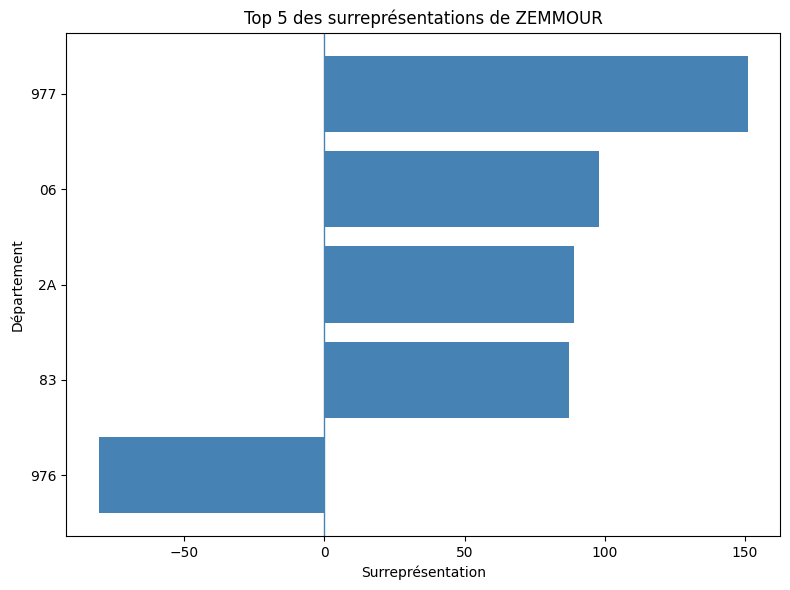

In [42]:
top5_surrepresentation("ZEMMOUR", score_departements, top=5)

## 3. Un peu de cartographie

### Question n°8

In [43]:
# Test fonction permettant de restreindre score_departements en fonction d’un candidat
score_Lepen = score_candidat("Marine LE PEN", score_departements)
score_Lepen

,code_departement,candidat,voix_dep,pourcentage_dep,voix_nat,pourcentage_nat,surrepresentation
1,01,Marine LE PEN,86755,0.260507,8133828,0.231516,12.522294
12,02,Marine LE PEN,104342,0.392470,8133828,0.231516,69.521877
24,03,Marine LE PEN,50315,0.270576,8133828,0.231516,16.871660
36,04,Marine LE PEN,26010,0.269024,8133828,0.231516,16.200991
50,05,Marine LE PEN,19696,0.228399,8133828,0.231516,-1.346144
...,...,...,...,...,...,...,...
1238,978,Marine LE PEN,853,0.148970,8133828,0.231516,-35.654633
1250,986,Marine LE PEN,579,0.108043,8133828,0.231516,-53.332514
1261,987,Marine LE PEN,11705,0.194986,8133828,0.231516,-15.778558
1273,988,Marine LE PEN,13273,0.188270,8133828,0.231516,-18.679587


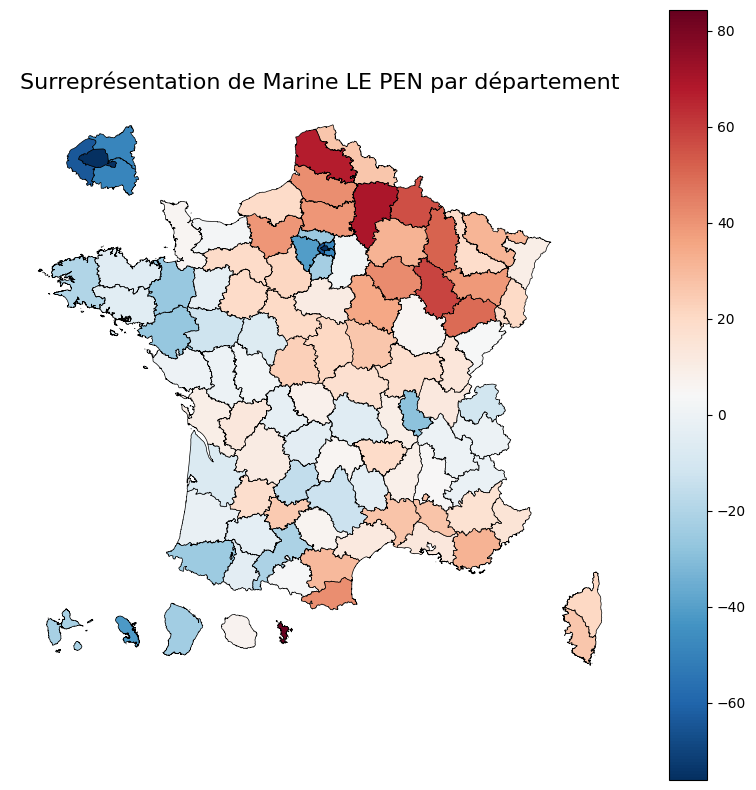

In [44]:
carte("Marine LE PEN", score_departements)

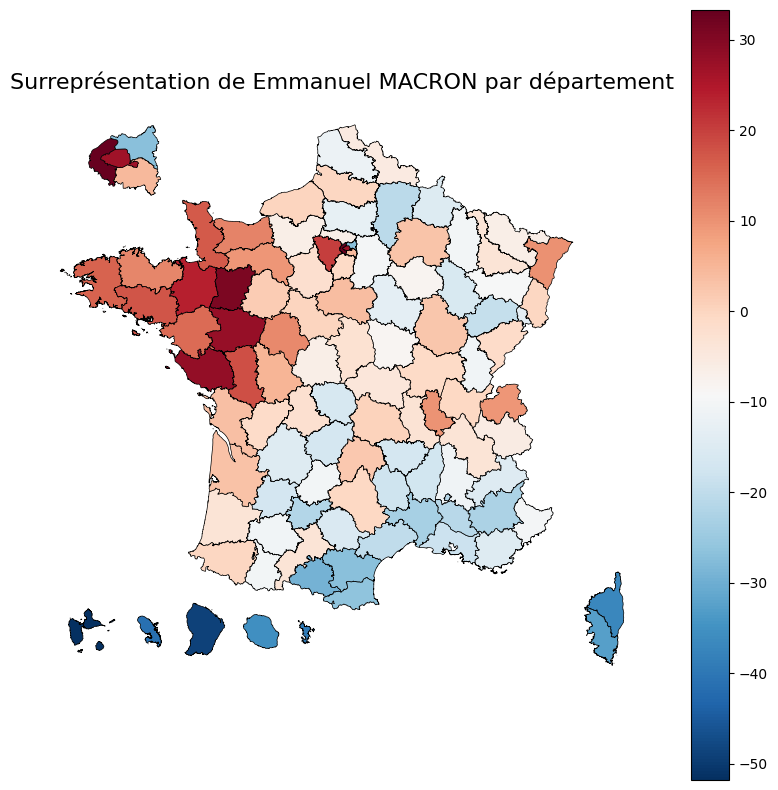

In [45]:
carte("Emmanuel MACRON", score_departements)

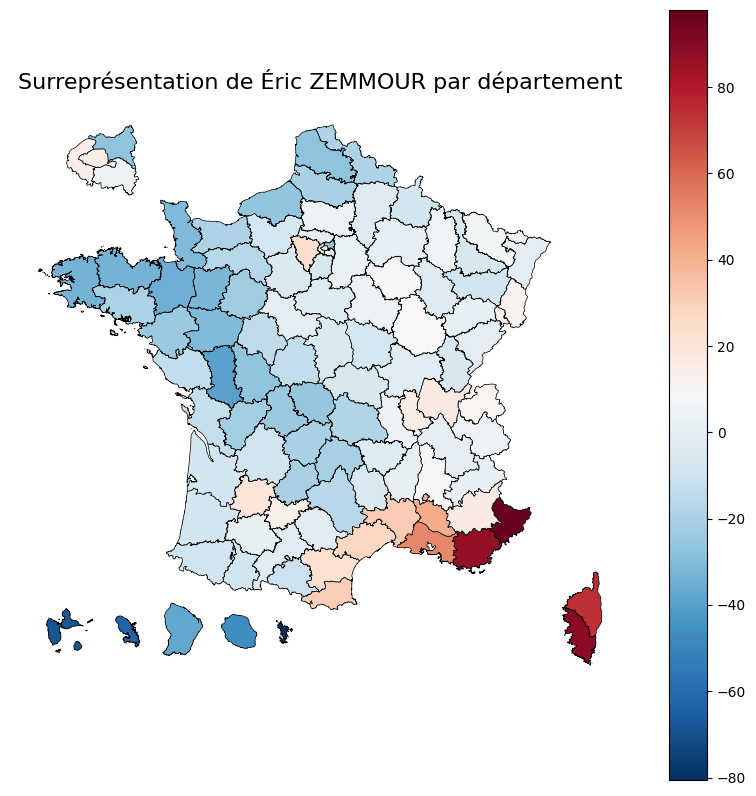

In [46]:
carte("Éric ZEMMOUR", score_departements)